In [30]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import chi2, SelectKBest

from xgboost import XGBClassifier
import joblib

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not available. ANN cell will be skipped.")


In [31]:
DATA_PATH = "D:/mental_health_project/mental_health_project/data/raw/Combined Data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Dataset Shape: (53043, 3)

Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [32]:
print("Data Info:")
df.info()


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   52681 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.2 MB


In [33]:
print("Missing Values:")
missing = df.isnull().sum()
print(missing)
print("\nTotal missing:", df.isnull().sum().sum())


Missing Values:
Unnamed: 0      0
statement     362
status          0
dtype: int64

Total missing: 362


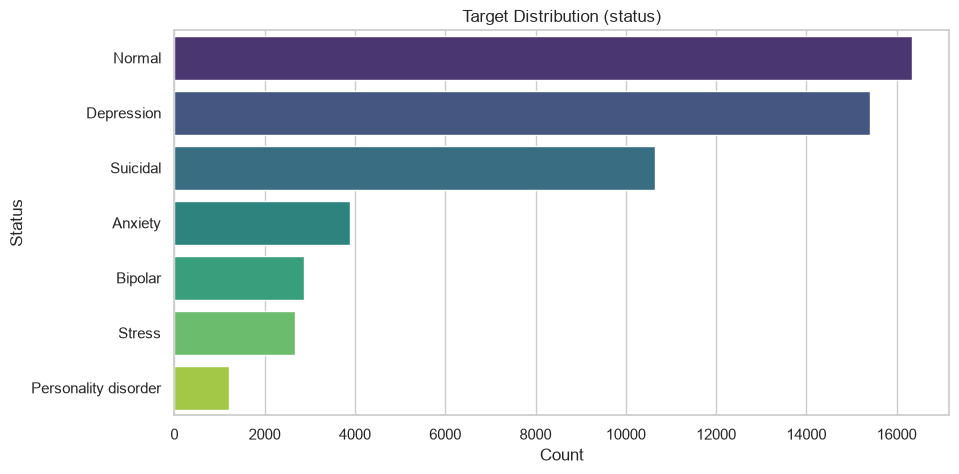

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

Percentage:
status
Normal                  30.825934
Depression              29.040590
Suicidal                20.083706
Anxiety                  7.329902
Bipolar                  5.423901
Stress                   5.031767
Personality disorder     2.264201
Name: proportion, dtype: float64


In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(y="status", data=df, order=df["status"].value_counts().index, palette="viridis")
plt.title("Target Distribution (status)")
plt.xlabel("Count")
plt.ylabel("Status")
plt.show()

print(df["status"].value_counts())
print("\nPercentage:")
print(df["status"].value_counts(normalize=True) * 100)


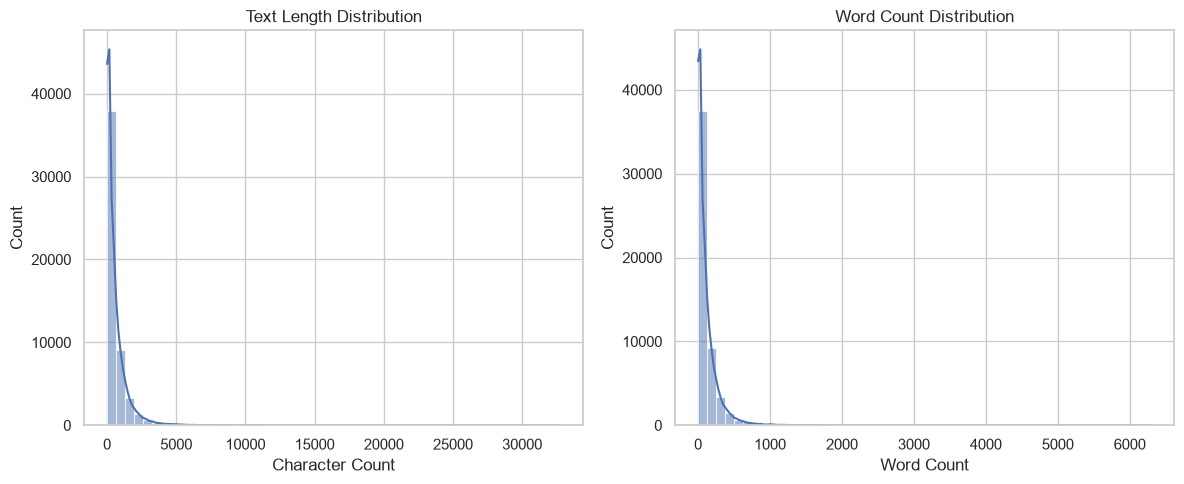

        text_length    word_count
count  53043.000000  53043.000000
mean     574.764342    112.386460
std      844.721094    163.441356
min        0.000000      0.000000
25%       77.000000     15.000000
50%      313.000000     61.000000
75%      748.000000    147.500000
max    32759.000000   6300.000000


In [35]:
if "df" not in globals():
    DATA_PATH = "D:/mental_health_project/mental_health_project/data/raw/Combined Data.csv"
    df = pd.read_csv(DATA_PATH)

df["text_length"] = (
    df["statement"]
    .fillna("")
    .astype(str)
    .str.len()
)
df["word_count"] = (
    df["statement"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Text Length Distribution")
plt.xlabel("Character Count")

plt.subplot(1, 2, 2)
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

print(df[["text_length", "word_count"]].describe())


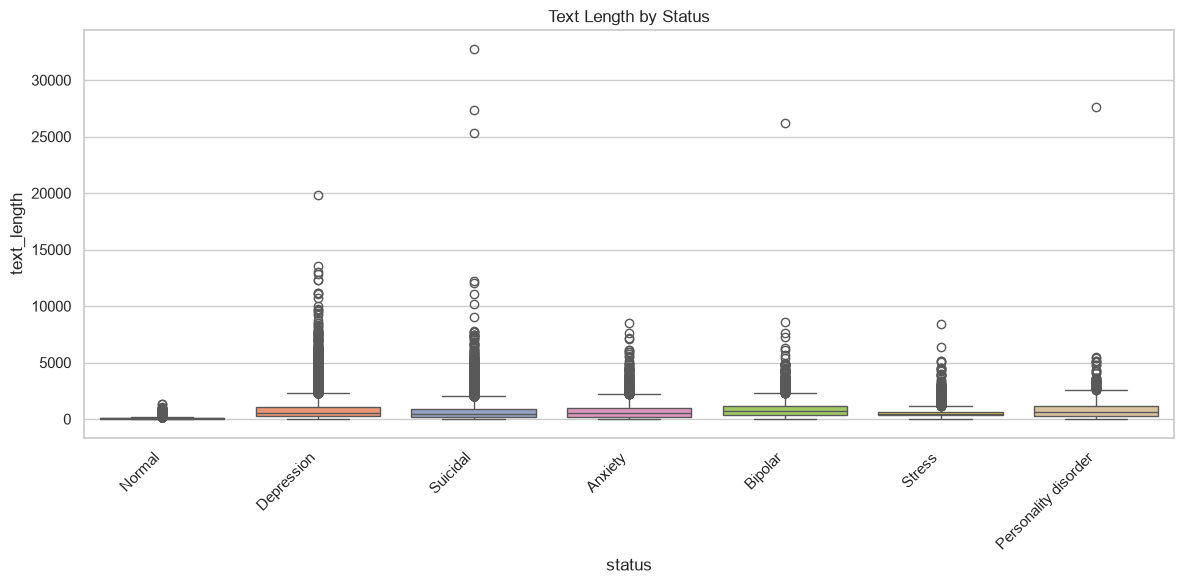

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="status", y="text_length", data=df, order=df["status"].value_counts().index, palette="Set2")
plt.title("Text Length by Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [37]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned_statement"] = df["statement"].apply(clean_text)

df = df.dropna(subset=["statement"]).reset_index(drop=True)
df["cleaned_statement"] = df["statement"].apply(clean_text)

print("Rows after cleaning:", len(df))
df[["statement", "cleaned_statement"]].head(10)


Rows after cleaning: 52681


,statement,cleaned_statement
0,oh my gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...
4,"I'm restless and restless, it's been a month n...",im restless and restless its been a month now ...
5,"every break, you must be nervous, like somethi...",every break you must be nervous like something...
6,"I feel scared, anxious, what can I do? And may...",i feel scared anxious what can i do and may my...
7,Have you ever felt nervous but didn't know why?,have you ever felt nervous but didnt know why
8,"I haven't slept well for 2 days, it's like I'm...",i havent slept well for days its like im restl...
9,"I'm really worried, I want to cry.",im really worried i want to cry


In [38]:
label_encoder = LabelEncoder()
df["status_encoded"] = label_encoder.fit_transform(df["status"])

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: {label}")

print(f"\nNumber of classes: {len(label_encoder.classes_)}")


Label mapping:
  0: Anxiety
  1: Bipolar
  2: Depression
  3: Normal
  4: Personality disorder
  5: Stress
  6: Suicidal

Number of classes: 7


In [39]:
X = df["cleaned_statement"]
y = df["status_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nTrain target distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest target distribution:")
print(pd.Series(y_test).value_counts())


Train shape: (42144,) (42144,)
Test shape: (10537,) (10537,)

Train target distribution:
status_encoded
3    13074
2    12323
6     8521
0     3073
1     2221
5     2070
4      862
Name: count, dtype: int64

Test target distribution:
status_encoded
3    3269
2    3081
6    2131
0     768
1     556
5     517
4     215
Name: count, dtype: int64


In [40]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    max_df=0.95,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

feature_names = tfidf.get_feature_names_out()
print("Vocabulary size:", len(feature_names))


TF-IDF train shape: (42144, 5000)
TF-IDF test shape: (10537, 5000)
Vocabulary size: 5000


In [41]:
print("=== FEATURE SELECTION ===")

selector = SelectKBest(score_func=chi2, k=3000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print("Features after selection:", X_train_selected.shape)

selected_features = [feature_names[i] for i in selector.get_support(indices=True)]
print("Top 10 selected features:", selected_features[:10])


=== FEATURE SELECTION ===
Features after selection: (42144, 3000)
Top 10 selected features: ['abandoned', 'abdomen', 'abdominal', 'abilify', 'ability', 'able', 'abnormal', 'absolute', 'absolutely', 'abuse']


In [42]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_f1 = f1_score(y_train, train_pred, average="weighted")
    test_f1 = f1_score(y_test, test_pred, average="weighted")
    
    print(f"=== {model_name} ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Train F1:       {train_f1:.4f}")
    print(f"Test F1:        {test_f1:.4f}")
    print()
    print("Classification Report (Test):")
    print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))
    
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return {
        "name": model_name,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1
    }


=== Logistic Regression ===
Train Accuracy: 0.8061
Test Accuracy:  0.7657
Train F1:       0.8023
Test F1:        0.7601

Classification Report (Test):
                      precision    recall  f1-score   support

             Anxiety       0.84      0.75      0.79       768
             Bipolar       0.86      0.71      0.78       556
          Depression       0.71      0.74      0.73      3081
              Normal       0.83      0.95      0.89      3269
Personality disorder       0.79      0.49      0.61       215
              Stress       0.65      0.43      0.52       517
            Suicidal       0.69      0.65      0.67      2131

            accuracy                           0.77     10537
           macro avg       0.77      0.67      0.71     10537
        weighted avg       0.76      0.77      0.76     10537



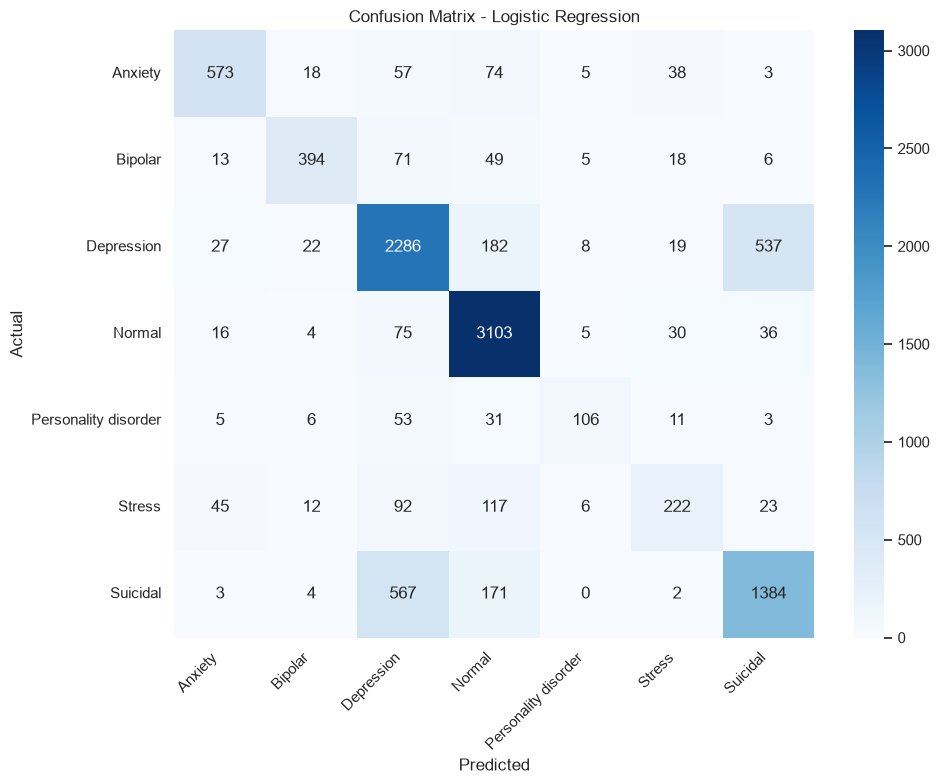

In [43]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_model.fit(X_train_selected, y_train)
lr_results = evaluate_model(lr_model, X_train_selected, X_test_selected, y_train, y_test, "Logistic Regression")


=== Decision Tree ===
Train Accuracy: 0.9974
Test Accuracy:  0.6635
Train F1:       0.9974
Test F1:        0.6608

Classification Report (Test):
                      precision    recall  f1-score   support

             Anxiety       0.63      0.61      0.62       768
             Bipolar       0.66      0.64      0.65       556
          Depression       0.63      0.61      0.62      3081
              Normal       0.81      0.87      0.84      3269
Personality disorder       0.61      0.51      0.56       215
              Stress       0.43      0.40      0.42       517
            Suicidal       0.53      0.53      0.53      2131

            accuracy                           0.66     10537
           macro avg       0.61      0.60      0.60     10537
        weighted avg       0.66      0.66      0.66     10537



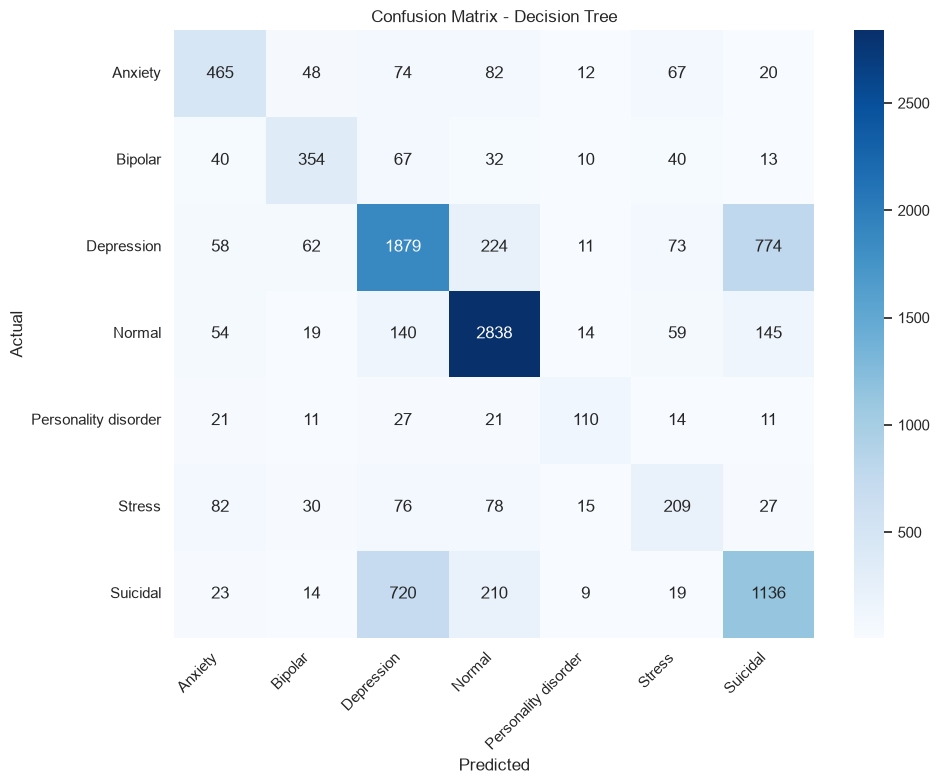

In [44]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_selected, y_train)
dt_results = evaluate_model(dt_model, X_train_selected, X_test_selected, y_train, y_test, "Decision Tree")


=== Random Forest ===
Train Accuracy: 0.9974
Test Accuracy:  0.7455
Train F1:       0.9974
Test F1:        0.7357

Classification Report (Test):
                      precision    recall  f1-score   support

             Anxiety       0.80      0.75      0.77       768
             Bipolar       0.94      0.65      0.77       556
          Depression       0.66      0.78      0.71      3081
              Normal       0.81      0.95      0.87      3269
Personality disorder       0.99      0.43      0.60       215
              Stress       0.83      0.33      0.48       517
            Suicidal       0.70      0.55      0.61      2131

            accuracy                           0.75     10537
           macro avg       0.82      0.63      0.69     10537
        weighted avg       0.75      0.75      0.74     10537



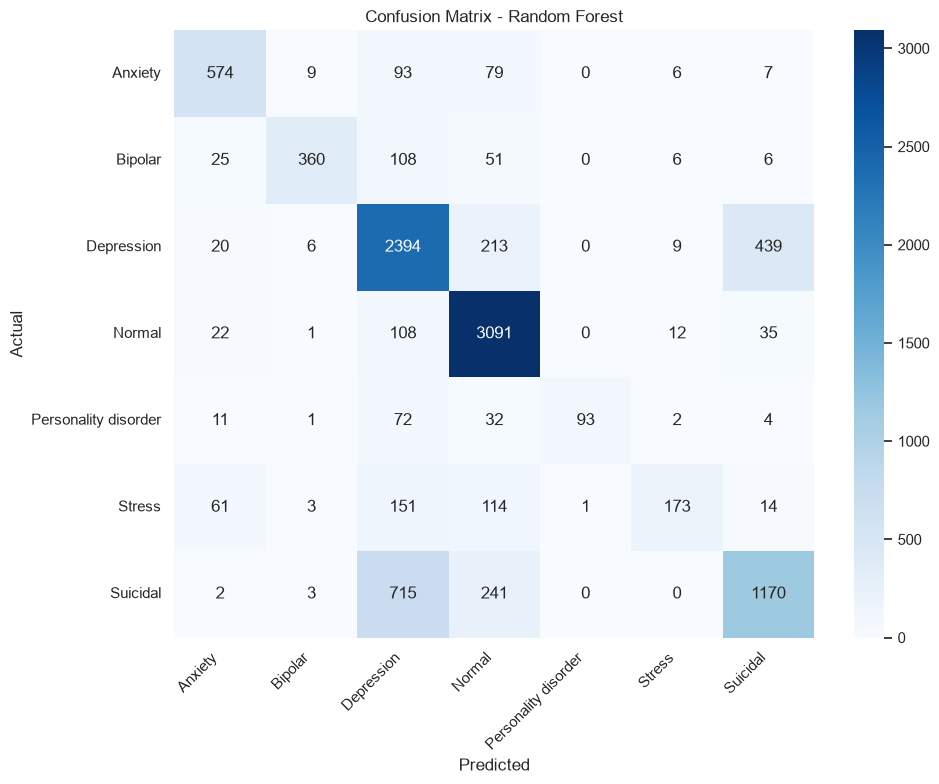

In [45]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)
rf_results = evaluate_model(rf_model, X_train_selected, X_test_selected, y_train, y_test, "Random Forest")


=== XGBoost ===
Train Accuracy: 0.8246
Test Accuracy:  0.7628
Train F1:       0.8219
Test F1:        0.7578

Classification Report (Test):
                      precision    recall  f1-score   support

             Anxiety       0.79      0.74      0.76       768
             Bipolar       0.89      0.74      0.81       556
          Depression       0.74      0.74      0.74      3081
              Normal       0.80      0.94      0.86      3269
Personality disorder       0.82      0.60      0.69       215
              Stress       0.63      0.50      0.55       517
            Suicidal       0.71      0.62      0.67      2131

            accuracy                           0.76     10537
           macro avg       0.77      0.70      0.73     10537
        weighted avg       0.76      0.76      0.76     10537



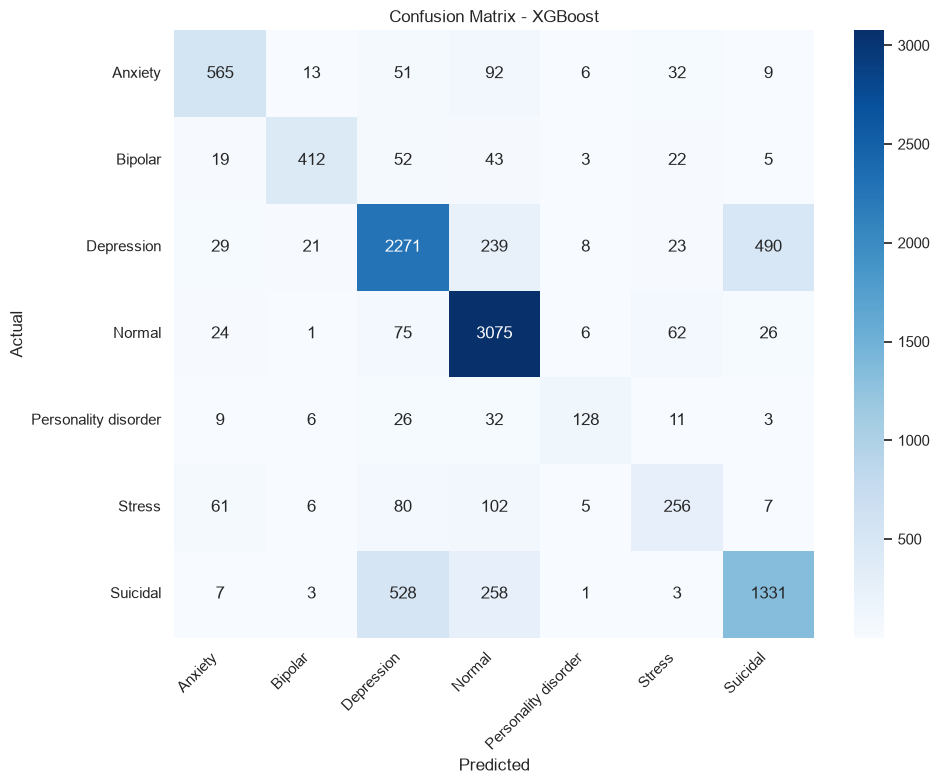

In [46]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb_model.fit(X_train_selected, y_train)
xgb_results = evaluate_model(xgb_model, X_train_selected, X_test_selected, y_train, y_test, "XGBoost")


ANN input dimension: 3000
Number of classes: 7
=== ANN ===
Train Accuracy: 0.9448
Test Accuracy:  0.7322
Train F1:       0.9446
Test F1:        0.7293

Classification Report (Test):
                      precision    recall  f1-score   support

             Anxiety       0.77      0.73      0.75       768
             Bipolar       0.76      0.74      0.75       556
          Depression       0.68      0.69      0.69      3081
              Normal       0.85      0.91      0.88      3269
Personality disorder       0.69      0.56      0.62       215
              Stress       0.53      0.45      0.49       517
            Suicidal       0.63      0.60      0.61      2131

            accuracy                           0.73     10537
           macro avg       0.70      0.67      0.68     10537
        weighted avg       0.73      0.73      0.73     10537



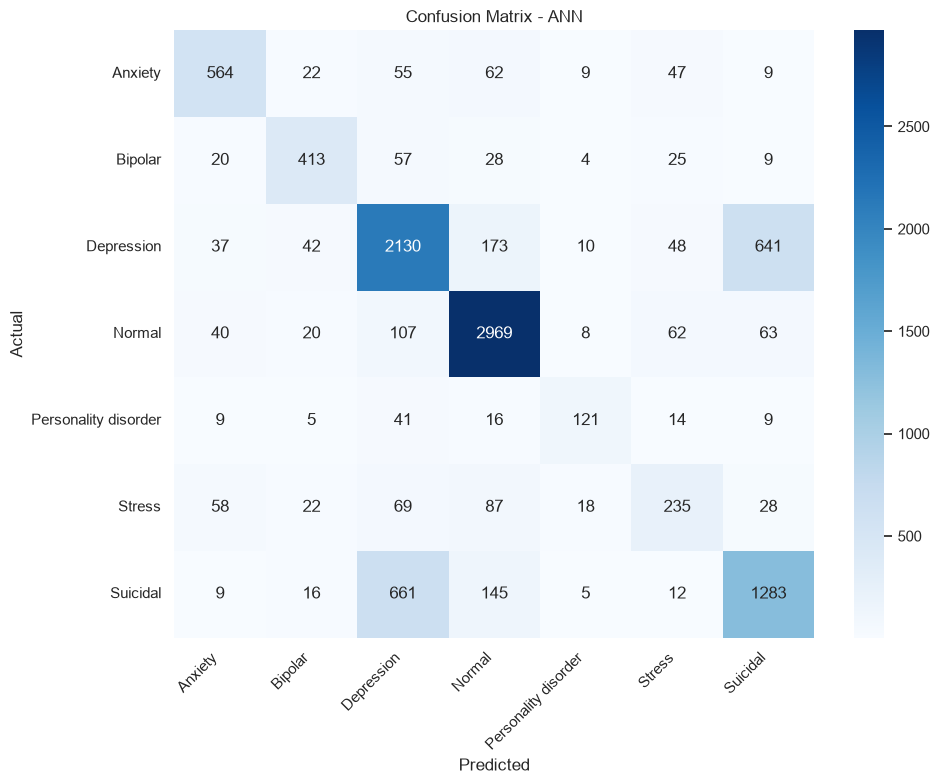

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

if not TF_AVAILABLE:
    print("TensorFlow not available. Skipping ANN.")
else:
    input_dim = X_train_selected.shape[1]
    n_classes = len(np.unique(y_train))
    print(f"ANN input dimension: {input_dim}")
    print(f"Number of classes: {n_classes}")
    
    # Convert sparse to dense (XGBoost features might be sparse)
    X_train_dense = X_train_selected.toarray() if hasattr(X_train_selected, "toarray") else X_train_selected
    X_test_dense = X_test_selected.toarray() if hasattr(X_test_selected, "toarray") else X_test_selected
    
    # Scale features for neural network
    scaler = StandardScaler()
    X_train_dense = scaler.fit_transform(X_train_dense)
    X_test_dense = scaler.transform(X_test_dense)
    
    model_ann = keras.Sequential([
        layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation="softmax")
    ])
    
    model_ann.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model_ann.fit(
        X_train_dense, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=128,
        verbose=0
    )
    
    train_loss, train_acc = model_ann.evaluate(X_train_dense, y_train, verbose=0)
    test_loss, test_acc = model_ann.evaluate(X_test_dense, y_test, verbose=0)
    
    y_train_pred_ann = model_ann.predict(X_train_dense, verbose=0).argmax(axis=1)
    y_test_pred_ann = model_ann.predict(X_test_dense, verbose=0).argmax(axis=1)
    
    train_f1 = f1_score(y_train, y_train_pred_ann, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred_ann, average="weighted")
    
    print(f"=== ANN ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Train F1:       {train_f1:.4f}")
    print(f"Test F1:        {test_f1:.4f}")
    print()
    print("Classification Report (Test):")
    print(classification_report(y_test, y_test_pred_ann, target_names=label_encoder.classes_))
    
    cm = confusion_matrix(y_test, y_test_pred_ann)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title("Confusion Matrix - ANN")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    ann_results = {
        "name": "ANN",
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1
    }


In [48]:
all_results = [lr_results, dt_results, rf_results, xgb_results]
if "ann_results" in globals():
    all_results.append(ann_results)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("test_f1", ascending=False)
print("Model Comparison (sorted by Test F1):")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["name"]
print(f"\nBest model by Test F1: {best_model_name}")


Model Comparison (sorted by Test F1):
               name  train_acc  test_acc  train_f1  test_f1
Logistic Regression   0.806141  0.765683  0.802315 0.760097
            XGBoost   0.824625  0.762836  0.821876 0.757786
      Random Forest   0.997390  0.745468  0.997391 0.735700
                ANN   0.944785  0.732182  0.944648 0.729270
      Decision Tree   0.997390  0.663472  0.997391 0.660761

Best model by Test F1: Logistic Regression


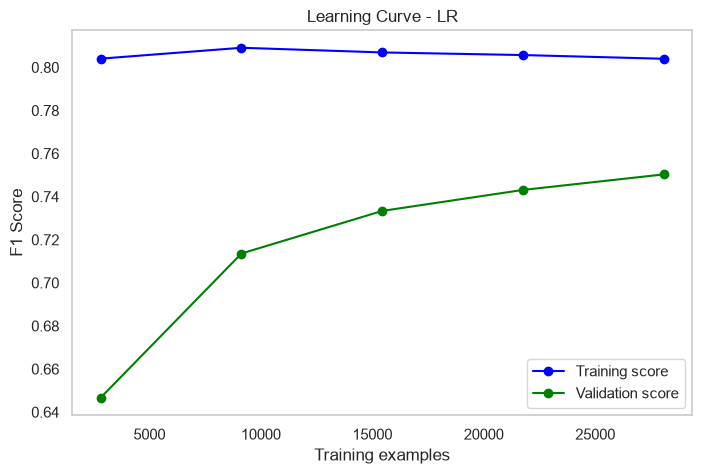

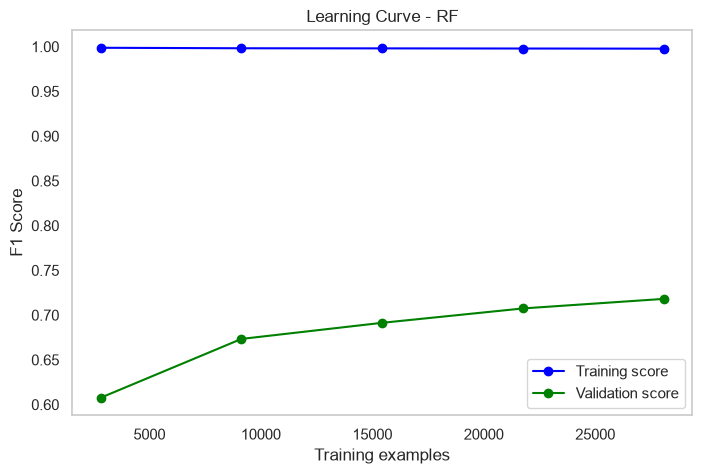

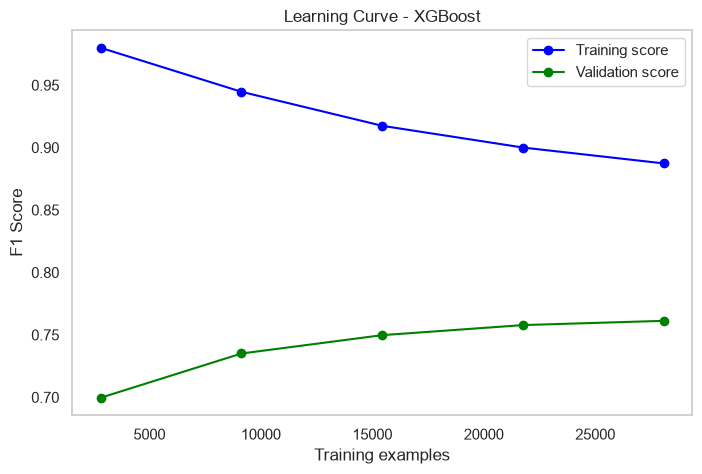

In [49]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=3):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5),
        scoring="f1_weighted", random_state=RANDOM_STATE
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training score")
    plt.plot(train_sizes, test_mean, "o-", color="green", label="Validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), "Learning Curve - LR", X_train_selected, y_train)
plot_learning_curve(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), "Learning Curve - RF", X_train_selected, y_train)
plot_learning_curve(XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss"), "Learning Curve - XGBoost", X_train_selected, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'colsample_bytree': np.float64(0.7139351238159992), 'learning_rate': np.float64(0.15150897038028768), 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 266, 'subsample': np.float64(0.7039794883479599)}
Best CV F1: 0.7700137793973365
=== Tuned XGBoost ===
Train Accuracy: 0.9113
Test Accuracy:  0.7761
Train F1:       0.9107
Test F1:        0.7732

Classification Report (Test):
                      precision    recall  f1-score   support

             Anxiety       0.81      0.78      0.79       768
             Bipolar       0.87      0.77      0.82       556
          Depression       0.73      0.75      0.74      3081
              Normal       0.85      0.93      0.89      3269
Personality disorder       0.83      0.62      0.71       215
              Stress       0.62      0.56      0.59       517
            Suicidal       0.70      0.65      0.67      2131

            accuracy                         

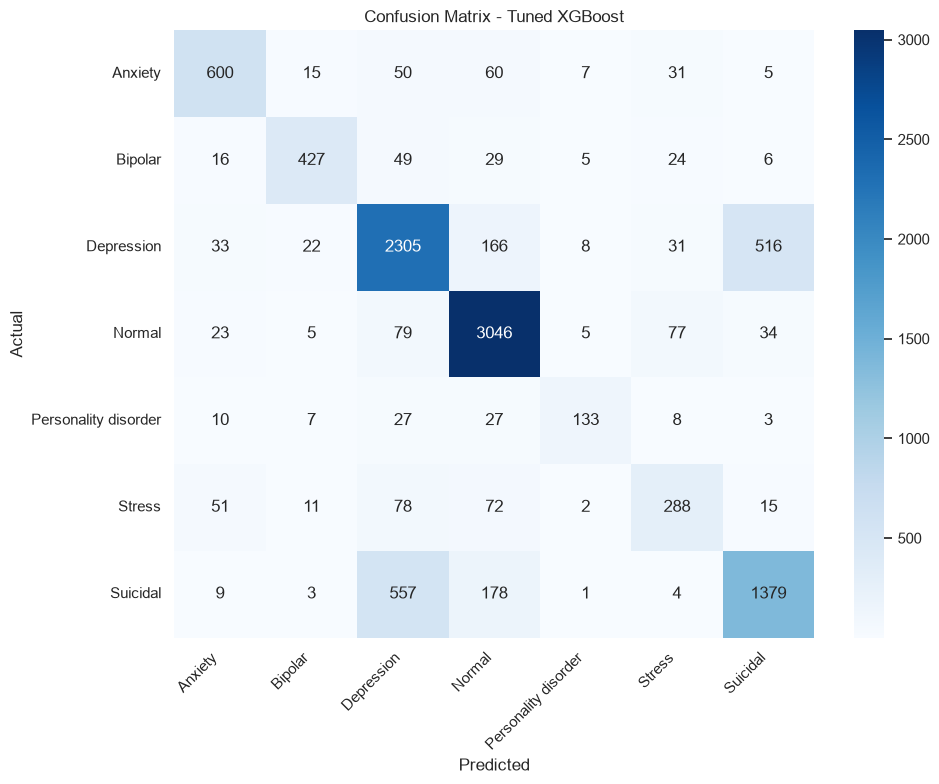

In [50]:
import scipy.stats as st

# Tune XGBoost using the already transformed feature matrices
xgb_base = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=1,
    random_state=RANDOM_STATE
)

param_dist = {
    "n_estimators": st.randint(100, 350),
    "max_depth": st.randint(3, 10),
    "learning_rate": st.uniform(0.03, 0.2),
    "subsample": st.uniform(0.7, 0.3),
    "colsample_bytree": st.uniform(0.7, 0.3),
    "min_child_weight": st.randint(1, 8)
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train_selected, y_train)

print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

# Preserve the pipeline structure used by later cells
best_model = Pipeline([
    ("tfidf", tfidf),
    ("selector", selector),
    ("classifier", random_search.best_estimator_)
])

tuned_results = evaluate_model(
    best_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Tuned XGBoost"
)


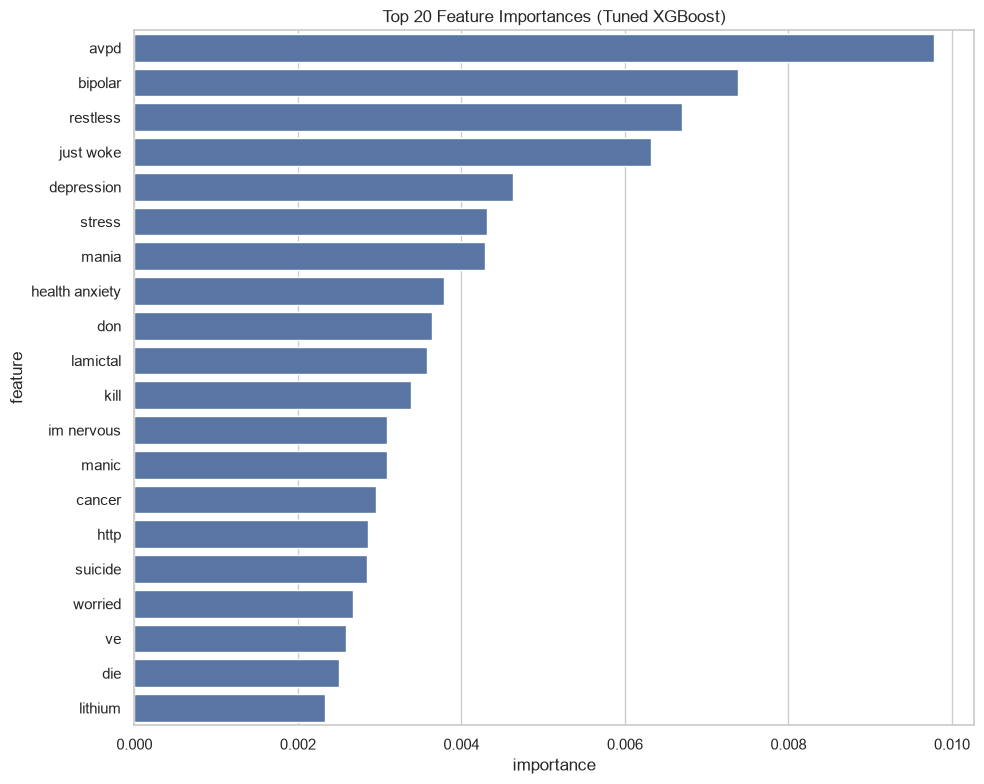

             feature  importance
176             avpd    0.009780
230          bipolar    0.007389
2220        restless    0.006693
1458       just woke    0.006321
521       depression    0.004634
2483          stress    0.004307
1728           mania    0.004286
1131  health anxiety    0.003789
639              don    0.003642
1517        lamictal    0.003578
1471            kill    0.003381
1280      im nervous    0.003094
1729           manic    0.003086
301           cancer    0.002958
1215            http    0.002851
2526         suicide    0.002848
2948         worried    0.002676
2797              ve    0.002587
577              die    0.002500
1631         lithium    0.002327


In [51]:
xgb_clf = best_model.named_steps["classifier"]
selected_features = [tfidf.get_feature_names_out()[i] for i in best_model.named_steps["selector"].get_support(indices=True)]
importances = xgb_clf.feature_importances_

imp_df = pd.DataFrame({"feature": selected_features, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=imp_df["importance"], y=imp_df["feature"])
plt.title("Top 20 Feature Importances (Tuned XGBoost)")
plt.tight_layout()
plt.show()

print(imp_df)


In [52]:
SAVE_DIR = "D:/mental_health_project/mental_health_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)


joblib.dump(best_model, os.path.join(SAVE_DIR, "structured_model_combined_data.pkl"))
print("Model saved to:", os.path.join(SAVE_DIR, "structured_model_combined_data.pkl"))

joblib.dump(tfidf, os.path.join(SAVE_DIR, "tfidf_vectorizer_combined_data.pkl"))
print("TF-IDF saved to:", os.path.join(SAVE_DIR, "tfidf_vectorizer_combined_data.pkl"))

joblib.dump(label_encoder, os.path.join(SAVE_DIR, "label_encoder_combined_data.pkl"))
print("Label encoder saved to:", os.path.join(SAVE_DIR, "label_encoder_combined_data.pkl"))


Model saved to: D:/mental_health_project/mental_health_project/models\structured_model_combined_data.pkl
TF-IDF saved to: D:/mental_health_project/mental_health_project/models\tfidf_vectorizer_combined_data.pkl
Label encoder saved to: D:/mental_health_project/mental_health_project/models\label_encoder_combined_data.pkl


In [53]:
print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print("Best Model: Tuned XGBoost")
acc = tuned_results["test_acc"]
f1 = tuned_results["test_f1"]
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1: {f1:.4f}")
print("\nModel saved successfully!")



FINAL MODEL SUMMARY
Best Model: Tuned XGBoost
Test Accuracy: 0.7761
Test F1: 0.7732

Model saved successfully!


## Project: Combined Data - Mental Health Statement Classification

### Process Summary
1. **EDA**: 53,043 rows, 3 columns. Target: `status` (7 classes: Normal, Depression, Suicidal, Anxiety, Bipolar, Stress, Personality disorder).
2. **Missing Values**: 362 null statements.
3. **Text Cleaning**: Lowercase, remove URLs/special chars, normalize whitespace.
4. **Feature Extraction**: TF-IDF with n-grams (1-2), 5000 max features, English stopwords.
5. **Feature Selection**: Chi-square, top 3000 features.
6. **Models**: Logistic Regression, Decision Tree, Random Forest, XGBoost, ANN.
7. **Best Model**: Tuned XGBoost via RandomizedSearchCV (15 iterations, 3-fold CV).
8. **Saved**: Model, TF-IDF vectorizer, and label encoder saved to `models/`.
